<a href="https://colab.research.google.com/github/Bhavana123448/PRODIGY_ML_02/blob/main/TASK02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
df = pd.read_csv("/content/Mall_Customers.csv")

print(df.head())


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


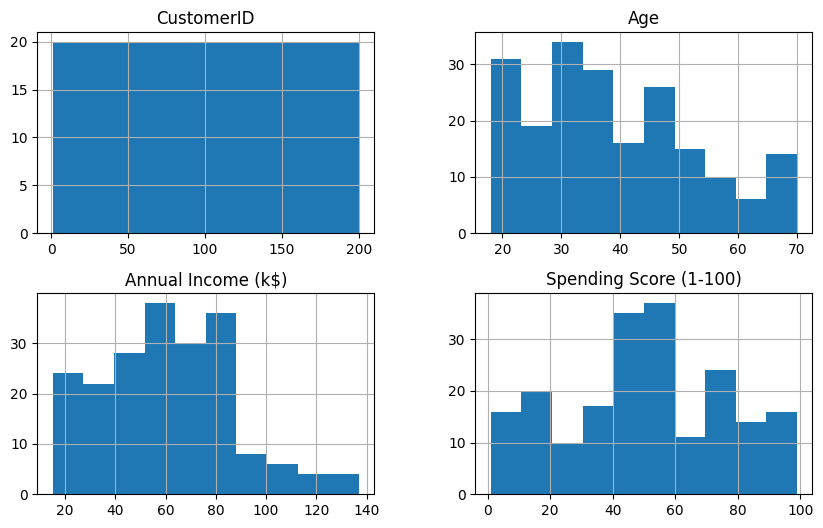

In [2]:
df.hist(figsize=(10,6))
plt.show()

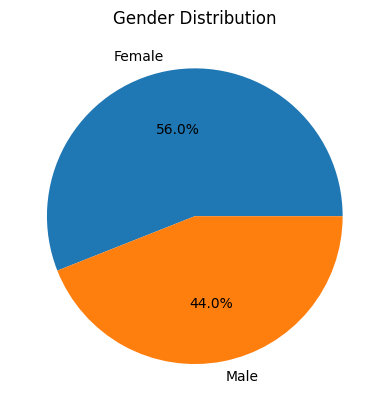

In [3]:
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

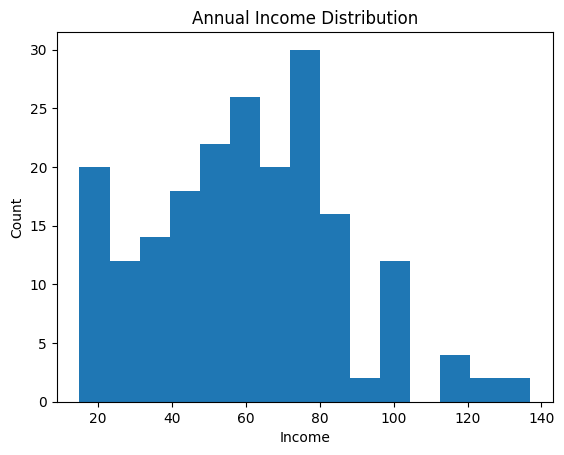

In [4]:
plt.hist(df['Annual Income (k$)'], bins=15)
plt.title('Annual Income Distribution')
plt.xlabel('Income')
plt.ylabel('Count')
plt.show()

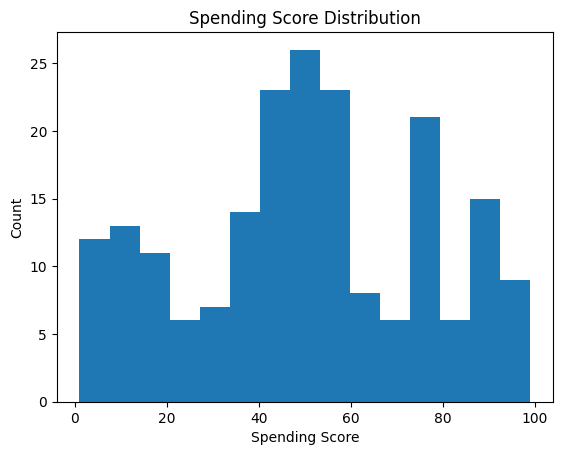

In [5]:
plt.hist(df['Spending Score (1-100)'], bins=15)
plt.title('Spending Score Distribution')
plt.xlabel('Spending Score')
plt.ylabel('Count')
plt.show()

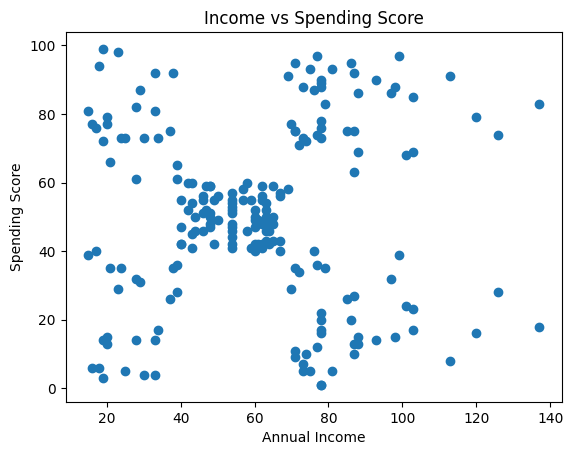

In [6]:
plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)']
)
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Income vs Spending Score')
plt.show()

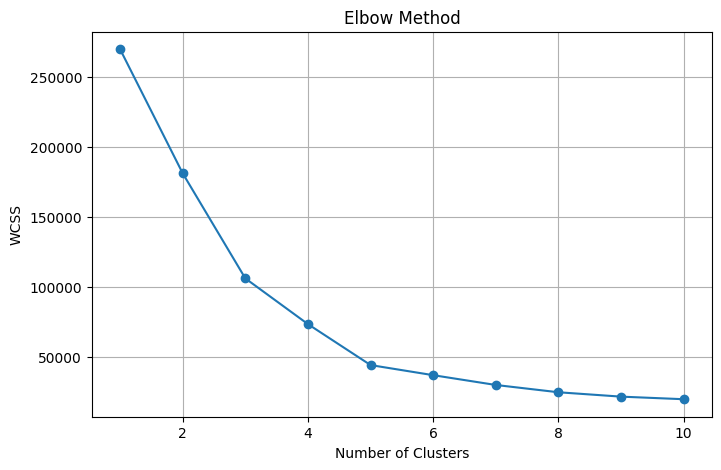

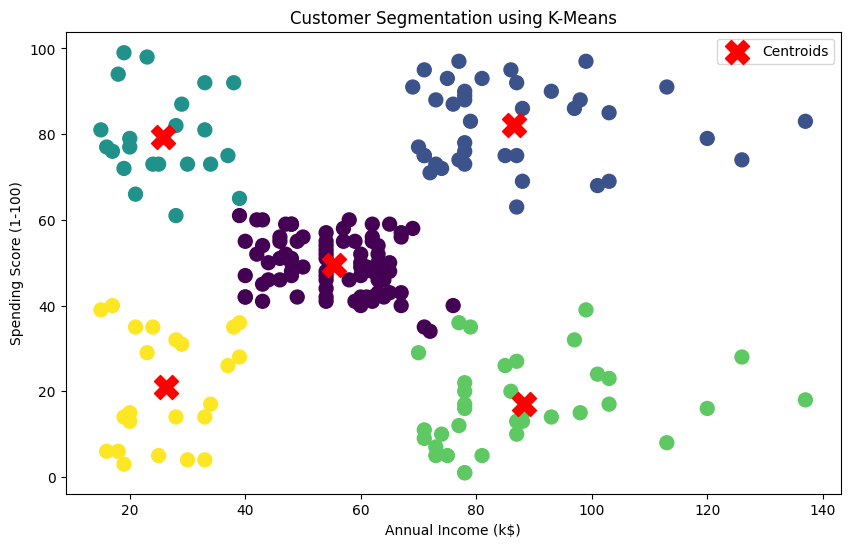

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


In [7]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)

df['Cluster'] = y_kmeans

plt.figure(figsize=(10,6))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=y_kmeans,
    cmap='viridis',
    s=100
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    c='red',
    marker='X',
    label='Centroids'
)

plt.title('Customer Segmentation using K-Means')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

print(df['Cluster'].value_counts())

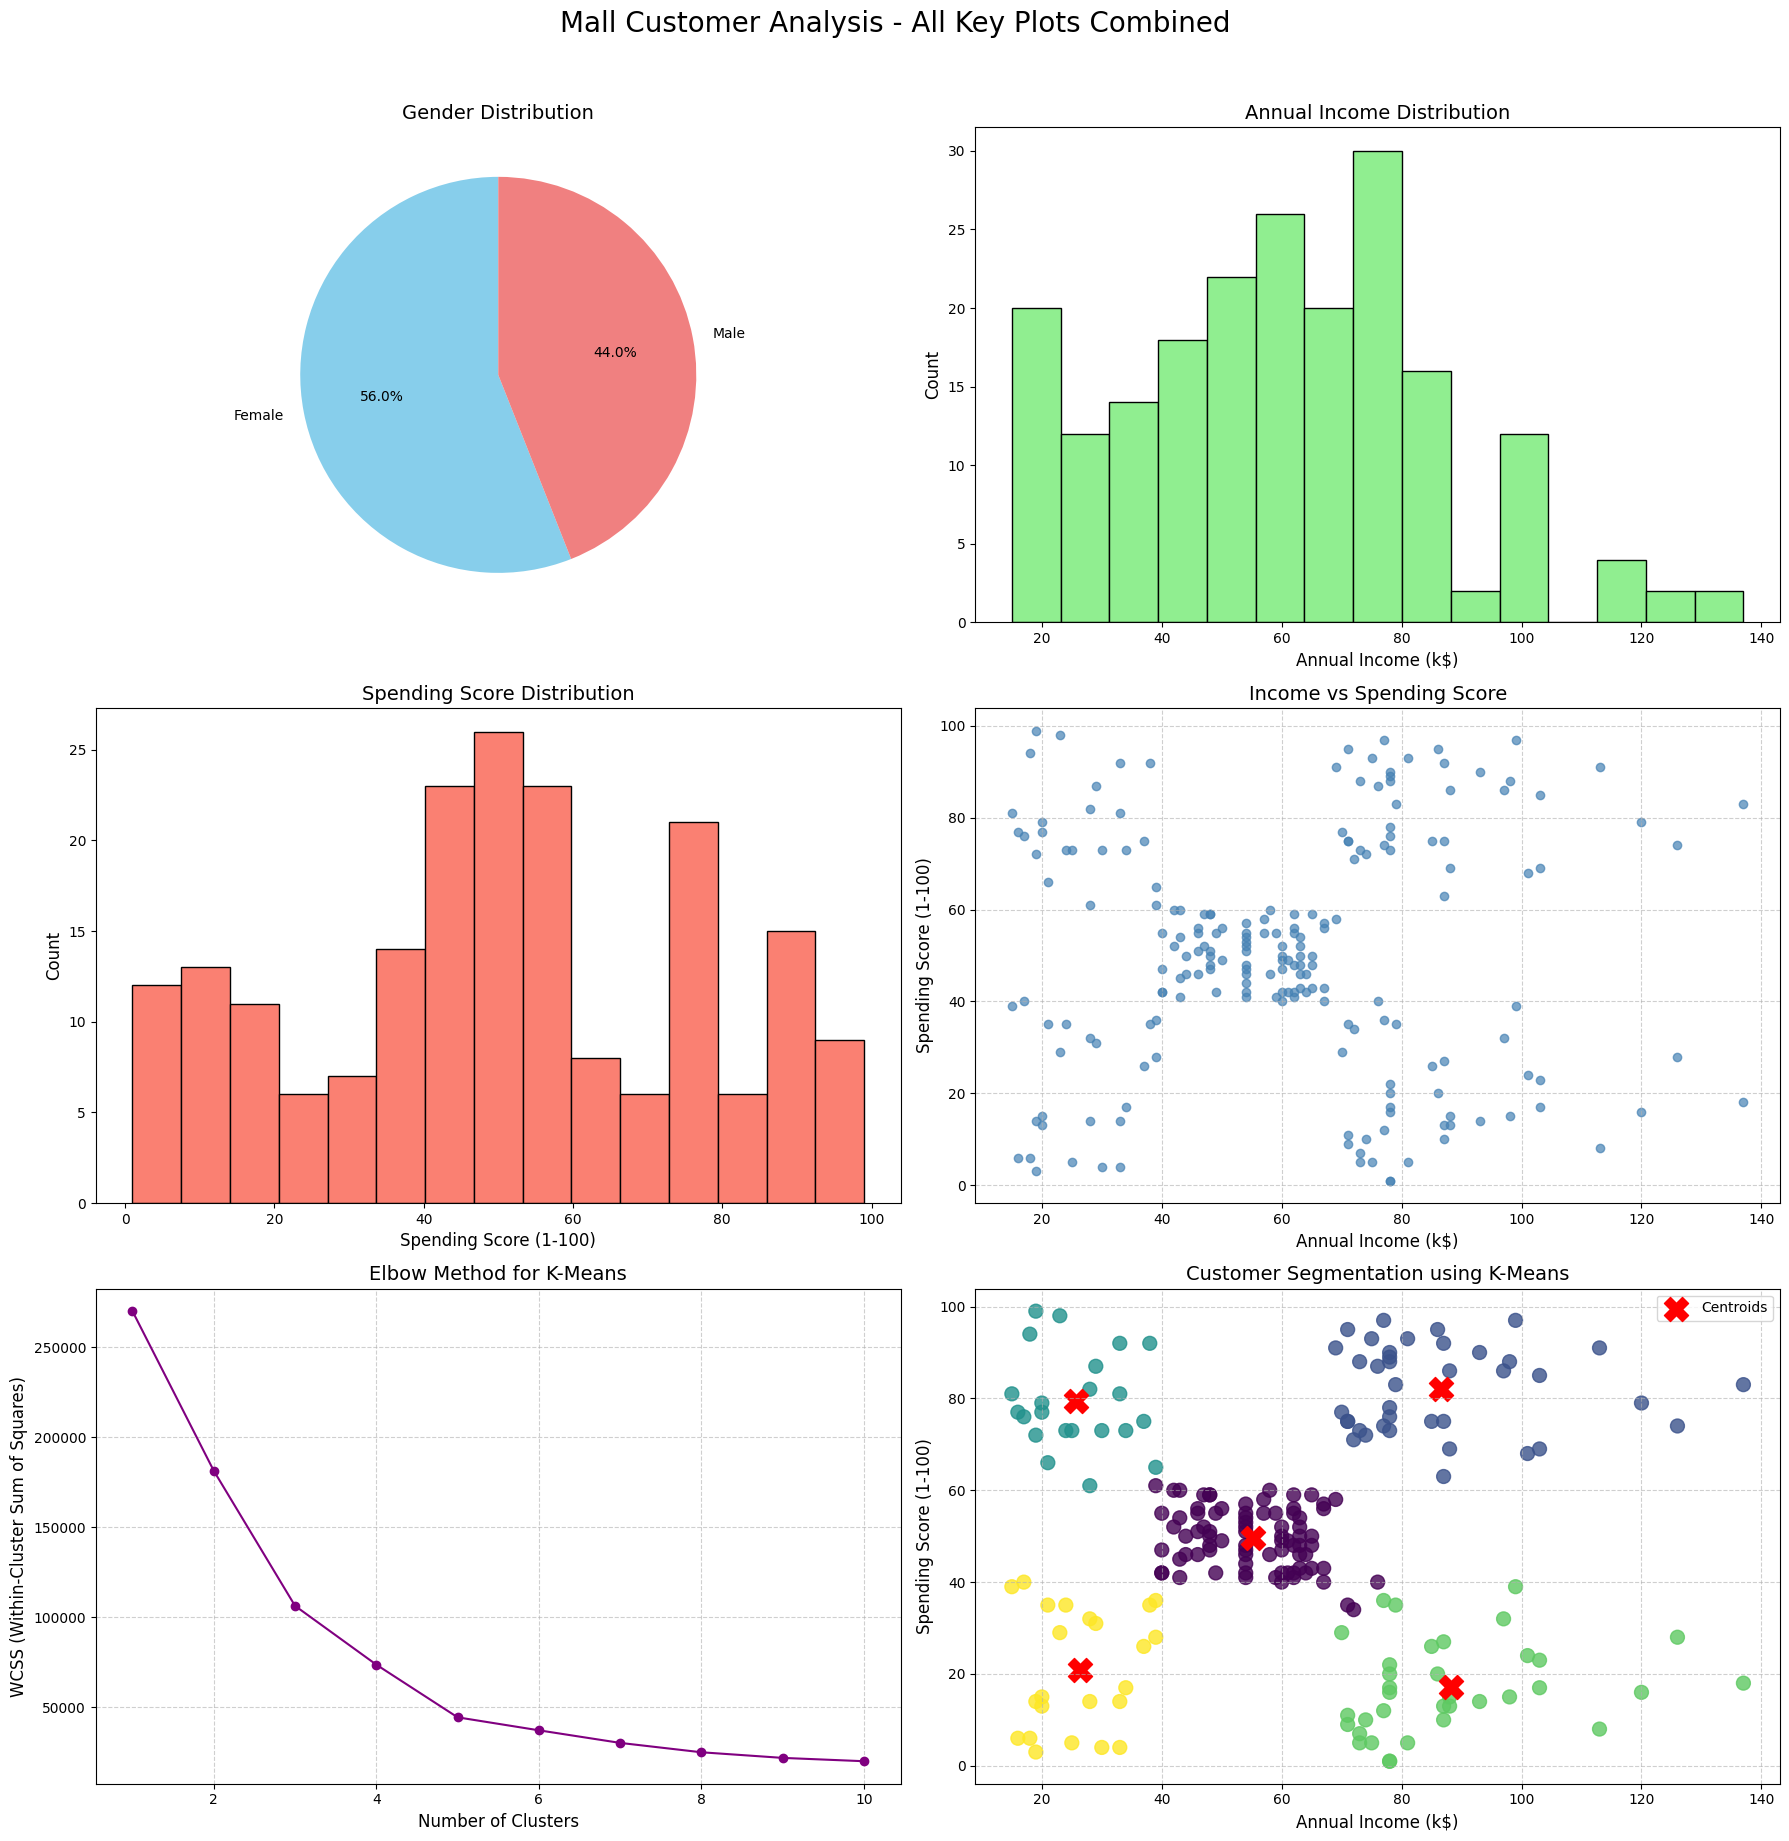

In [8]:
import matplotlib.pyplot as plt

# Create a figure and a 3x2 grid of subplots
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
fig.suptitle('Mall Customer Analysis - All Key Plots Combined', fontsize=20, y=1.02)

# Plot 1: Gender Distribution (Pie Chart)
if 'Gender' in df.columns:
    df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[0, 0], startangle=90, colors=['skyblue', 'lightcoral'])
    axes[0, 0].set_title('Gender Distribution', fontsize=14)
    axes[0, 0].set_ylabel('') # Remove 'Gender' label

# Plot 2: Annual Income Distribution (Histogram)
if 'Annual Income (k$)' in df.columns:
    axes[0, 1].hist(df['Annual Income (k$)'], bins=15, color='lightgreen', edgecolor='black')
    axes[0, 1].set_title('Annual Income Distribution', fontsize=14)
    axes[0, 1].set_xlabel('Annual Income (k$)', fontsize=12)
    axes[0, 1].set_ylabel('Count', fontsize=12)

# Plot 3: Spending Score Distribution (Histogram)
if 'Spending Score (1-100)' in df.columns:
    axes[1, 0].hist(df['Spending Score (1-100)'], bins=15, color='salmon', edgecolor='black')
    axes[1, 0].set_title('Spending Score Distribution', fontsize=14)
    axes[1, 0].set_xlabel('Spending Score (1-100)', fontsize=12)
    axes[1, 0].set_ylabel('Count', fontsize=12)

# Plot 4: Income vs Spending Score (Scatter Plot)
if 'Annual Income (k$)' in df.columns and 'Spending Score (1-100)' in df.columns:
    axes[1, 1].scatter(
        df['Annual Income (k$)'],
        df['Spending Score (1-100)'],
        color='steelblue', alpha=0.7
    )
    axes[1, 1].set_title('Income vs Spending Score', fontsize=14)
    axes[1, 1].set_xlabel('Annual Income (k$)', fontsize=12)
    axes[1, 1].set_ylabel('Spending Score (1-100)', fontsize=12)
    axes[1, 1].grid(True, linestyle='--', alpha=0.6)

# Plot 5: Elbow Method (from K-Means clustering)
# Assuming X and wcss are available from previous cell
if 'wcss' in locals() and 'X' in locals():
    axes[2, 0].plot(range(1, 11), wcss, marker='o', linestyle='-', color='purple')
    axes[2, 0].set_title('Elbow Method for K-Means', fontsize=14)
    axes[2, 0].set_xlabel('Number of Clusters', fontsize=12)
    axes[2, 0].set_ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
    axes[2, 0].grid(True, linestyle='--', alpha=0.6)

# Plot 6: Customer Segmentation using K-Means (Scatter Plot)
# Assuming X, y_kmeans, and kmeans are available from previous cell
if 'y_kmeans' in locals() and 'kmeans' in locals() and 'X' in locals():
    axes[2, 1].scatter(
        X.iloc[:, 0],
        X.iloc[:, 1],
        c=y_kmeans,
        cmap='viridis',
        s=100, alpha=0.8
    )
    axes[2, 1].scatter(
        kmeans.cluster_centers_[:, 0],
        kmeans.cluster_centers_[:, 1],
        s=300,
        c='red',
        marker='X',
        label='Centroids'
    )
    axes[2, 1].set_title('Customer Segmentation using K-Means', fontsize=14)
    axes[2, 1].set_xlabel('Annual Income (k$)', fontsize=12)
    axes[2, 1].set_ylabel('Spending Score (1-100)', fontsize=12)
    axes[2, 1].legend(fontsize=10)
    axes[2, 1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('all_plots_combined.png', bbox_inches='tight')
plt.show()

In [10]:
from google.colab import files

files.download('all_plots_combined.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>